# Cards Proposal Initiation

This notebook helps initiate new card proposals based on model insights and balance predictions from the Teklovossen ML pipeline.


## Setup and Imports

In [3]:
import sys
import os
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Any, Optional

# Add parent directory to path for importing modules
sys.path.append('../scripts')
sys.path.append('../data')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Environment setup complete!")

Environment setup complete!


## Import Teklo Models and Analytics

In [4]:
try:
    from sagemaker_integration import TekloSageMakerOrchestrator
    from data_analytics import TekloDataAnalyzer
    print("✅ Successfully imported Teklo modules")
except ImportError as e:
    print(f"❌ Failed to import modules: {e}")
    print("Please ensure the scripts directory contains the required modules")

✅ Successfully imported Teklo modules


## Card Proposal Template

Define the structure for new card proposals

In [5]:
class CardProposal:
    """Class to represent a new card proposal"""
    
    def __init__(self, name: str = "", card_type: str = ""):
        self.name = name
        self.card_type = card_type  # 'equipment', 'action', 'item'
        self.cost = 0
        self.archetype = ""  # 'AI', 'Nano', 'Quantum', 'Base'
        self.description = ""
        self.abilities = []
        
        # Balance prediction features
        self.features = {
            'AI': 0, 'Nano': 0, 'Quantum': 0, 'Base': 0,
            '0_cost': 0, '1_cost': 0, '2_cost': 0, '3_cost': 0, '4_plus_cost': 0,
            'equipment': 0, 'item': 0, 'action': 0,
            'avg_turns': 0, 'avg_evos': 0, 'avg_teklo_energy': 0,
            'avg_nanite_counters': 0, 'avg_quantum_charges': 0,
            'consistency_score': 0, 'avg_expert_balance_score': 0
        }
        
        # Predictions
        self.predicted_win_rate = None
        self.predicted_balance_score = None
        self.balance_assessment = ""
    
    def set_archetype(self, archetype: str):
        """Set card archetype and update features"""
        # Reset archetype features
        for arch in ['AI', 'Nano', 'Quantum', 'Base']:
            self.features[arch] = 0
        
        if archetype in ['AI', 'Nano', 'Quantum', 'Base']:
            self.archetype = archetype
            self.features[archetype] = 1
    
    def set_cost(self, cost: int):
        """Set card cost and update features"""
        # Reset cost features
        for cost_key in ['0_cost', '1_cost', '2_cost', '3_cost', '4_plus_cost']:
            self.features[cost_key] = 0
        
        self.cost = cost
        if cost == 0:
            self.features['0_cost'] = 1
        elif cost == 1:
            self.features['1_cost'] = 1
        elif cost == 2:
            self.features['2_cost'] = 1
        elif cost == 3:
            self.features['3_cost'] = 1
        else:
            self.features['4_plus_cost'] = 1
    
    def set_type(self, card_type: str):
        """Set card type and update features"""
        # Reset type features
        for type_key in ['equipment', 'item', 'action']:
            self.features[type_key] = 0
        
        if card_type.lower() in ['equipment', 'item', 'action']:
            self.card_type = card_type.lower()
            self.features[card_type.lower()] = 1
    
    def to_dict(self) -> Dict:
        """Convert proposal to dictionary"""
        return {
            'name': self.name,
            'card_type': self.card_type,
            'cost': self.cost,
            'archetype': self.archetype,
            'description': self.description,
            'abilities': self.abilities,
            'features': self.features,
            'predicted_win_rate': self.predicted_win_rate,
            'predicted_balance_score': self.predicted_balance_score,
            'balance_assessment': self.balance_assessment
        }

print("Card proposal template created!")

Card proposal template created!


## Load Existing Data for Context

In [6]:
# Initialize data analyzer
try:
    analyzer = TekloDataAnalyzer("../data")
    
    # Try to load existing data
    try:
        analyzer.load_simulation_data()
        analyzer.load_ml_data()
        print(f"✅ Loaded simulation data: {len(analyzer.simulation_data)} records")
        print(f"✅ Loaded ML data: {len(analyzer.ml_data)} records")
        
        # Show summary statistics
        if hasattr(analyzer, 'ml_data') and analyzer.ml_data is not None:
            print("\n📊 Current Balance Metrics:")
            if 'avg_win_rate' in analyzer.ml_data.columns:
                print(f"Win rate range: {analyzer.ml_data['avg_win_rate'].min():.2f} - {analyzer.ml_data['avg_win_rate'].max():.2f}")
            if 'avg_expert_balance_score' in analyzer.ml_data.columns:
                print(f"Balance score range: {analyzer.ml_data['avg_expert_balance_score'].min():.2f} - {analyzer.ml_data['avg_expert_balance_score'].max():.2f}")
                
    except Exception as e:
        print(f"⚠️ No existing data found: {e}")
        print("You may need to run simulations first")
        analyzer = None
        
except Exception as e:
    print(f"❌ Failed to initialize analyzer: {e}")
    analyzer = None

Loaded simulation data: 270 games from batch_simulation_20251021_000710.csv
Loaded ML training data: 9 deck configurations from ml_training_data_20251021_000713.csv
✅ Loaded simulation data: 270 records
✅ Loaded ML data: 9 records

📊 Current Balance Metrics:
Win rate range: 0.00 - 0.67
Balance score range: 5.00 - 6.67


## Balance Prediction Helper Functions

In [8]:
def predict_card_balance(card_proposal: CardProposal, use_sagemaker: bool = False) -> Dict[str, float]:
    """Predict card balance using available models"""
    predictions = {}
    
    if use_sagemaker:
        # Try to use SageMaker models if deployed
        try:
            orchestrator = TekloSageMakerOrchestrator()
            if orchestrator.deployed_endpoints:
                predictions = orchestrator.predict_card_balance(card_proposal.features)
                print("✅ Used SageMaker endpoints for prediction")
            else:
                print("⚠️ No deployed SageMaker endpoints found")
        except Exception as e:
            print(f"❌ SageMaker prediction failed: {e}")
    
    # Fallback: Use local model approximation if available
    if not predictions and analyzer and hasattr(analyzer, 'ml_data'):
        try:
            # Simple baseline prediction based on similar cards
            ml_data = analyzer.ml_data
            
            # Find cards with similar archetype and cost
            similar_mask = (
                (ml_data[card_proposal.archetype] == 1) & 
                (ml_data[f'{card_proposal.cost}_cost'] == 1) &
                (ml_data[card_proposal.card_type] == 1)
            )
            
            similar_cards = ml_data[similar_mask]
            
            if len(similar_cards) > 0:
                if 'avg_win_rate' in ml_data.columns:
                    predictions['balance_predictor'] = similar_cards['avg_win_rate'].mean()
                if 'avg_expert_balance_score' in ml_data.columns:
                    predictions['balance_scorer'] = similar_cards['avg_expert_balance_score'].mean()
                print(f"✅ Found {len(similar_cards)} similar cards for baseline prediction")
            else:
                # Use overall averages as fallback
                if 'avg_win_rate' in ml_data.columns:
                    predictions['balance_predictor'] = ml_data['avg_win_rate'].mean()
                if 'avg_expert_balance_score' in ml_data.columns:
                    predictions['balance_scorer'] = ml_data['avg_expert_balance_score'].mean()
                print("⚠️ No similar cards found, using overall averages")
                
        except Exception as e:
            print(f"❌ Baseline prediction failed: {e}")
    
    if not predictions:
        # Ultimate fallback: reasonable defaults
        predictions = {
            'balance_predictor': 0.5,  # 50% win rate
            'balance_scorer': 5.0      # Neutral balance score
        }
        print("⚠️ Using default predictions - run simulations for better estimates")
    
    return predictions

def assess_balance(win_rate: float, balance_score: float) -> str:
    """Assess card balance based on predictions"""
    if win_rate > 0.65 or balance_score > 8:
        return "🔴 OVERPOWERED - Consider reducing power level"
    elif win_rate < 0.35 or balance_score < 2:
        return "🔵 UNDERPOWERED - Consider increasing power level"
    elif 0.45 <= win_rate <= 0.55 and 4 <= balance_score <= 6:
        return "🟢 WELL BALANCED - Good design!"
    else:
        return "🟡 MODERATE - Minor adjustments may be needed"

print("Balance prediction helpers ready!")

Balance prediction helpers ready!


## Create New Card Proposal

Use this section to create and test new card ideas

In [9]:
# Create a new card proposal
new_card = CardProposal()

# Set basic properties
new_card.name = "Quantum Resonator"  # Change this!
new_card.description = "An advanced quantum device that amplifies resonance patterns"
new_card.abilities = [
    "When played: Gain 1 Quantum Charge",
    "Activated: Pay 2 Quantum Charges to draw a card"
]

# Set card properties (update features automatically)
new_card.set_archetype("Quantum")  # AI, Nano, Quantum, or Base
new_card.set_type("equipment")     # equipment, action, or item  
new_card.set_cost(2)               # Resource cost

# Set additional gameplay features (estimated impact)
new_card.features.update({
    'avg_turns': 0.5,              # Expected turns impact
    'avg_evos': 0.2,               # Evolution impact
    'avg_teklo_energy': 0.1,       # Energy impact
    'avg_nanite_counters': 0.0,    # Nanite impact
    'avg_quantum_charges': 1.2,    # Quantum impact
    'consistency_score': 0.3       # Consistency boost
})

print(f"Created proposal: {new_card.name}")
print(f"Type: {new_card.card_type.title()}, Cost: {new_card.cost}, Archetype: {new_card.archetype}")
print(f"Description: {new_card.description}")
print("Abilities:")
for ability in new_card.abilities:
    print(f"  • {ability}")

Created proposal: Quantum Resonator
Type: Equipment, Cost: 2, Archetype: Quantum
Description: An advanced quantum device that amplifies resonance patterns
Abilities:
  • When played: Gain 1 Quantum Charge
  • Activated: Pay 2 Quantum Charges to draw a card


## Balance Prediction and Assessment

In [10]:
# Get balance predictions
print("🔮 Predicting card balance...")
predictions = predict_card_balance(new_card, use_sagemaker=False)

# Update card with predictions
new_card.predicted_win_rate = predictions.get('balance_predictor', 0.5)
new_card.predicted_balance_score = predictions.get('balance_scorer', 5.0)

# Assess balance
new_card.balance_assessment = assess_balance(
    new_card.predicted_win_rate, 
    new_card.predicted_balance_score
)

# Display results
print(f"\n📊 Balance Analysis for '{new_card.name}':")
print(f"Predicted Win Rate: {new_card.predicted_win_rate:.1%}")
print(f"Predicted Balance Score: {new_card.predicted_balance_score:.1f}/10")
print(f"Assessment: {new_card.balance_assessment}")

# Show feature breakdown
print("\n🔧 Feature Analysis:")
active_features = {k: v for k, v in new_card.features.items() if v > 0}
for feature, value in active_features.items():
    print(f"  {feature}: {value}")

🔮 Predicting card balance...
⚠️ No similar cards found, using overall averages

📊 Balance Analysis for 'Quantum Resonator':
Predicted Win Rate: 19.6%
Predicted Balance Score: 5.3/10
Assessment: 🔵 UNDERPOWERED - Consider increasing power level

🔧 Feature Analysis:
  Quantum: 1
  2_cost: 1
  equipment: 1
  avg_turns: 0.5
  avg_evos: 0.2
  avg_teklo_energy: 0.1
  avg_quantum_charges: 1.2
  consistency_score: 0.3


## Visualization

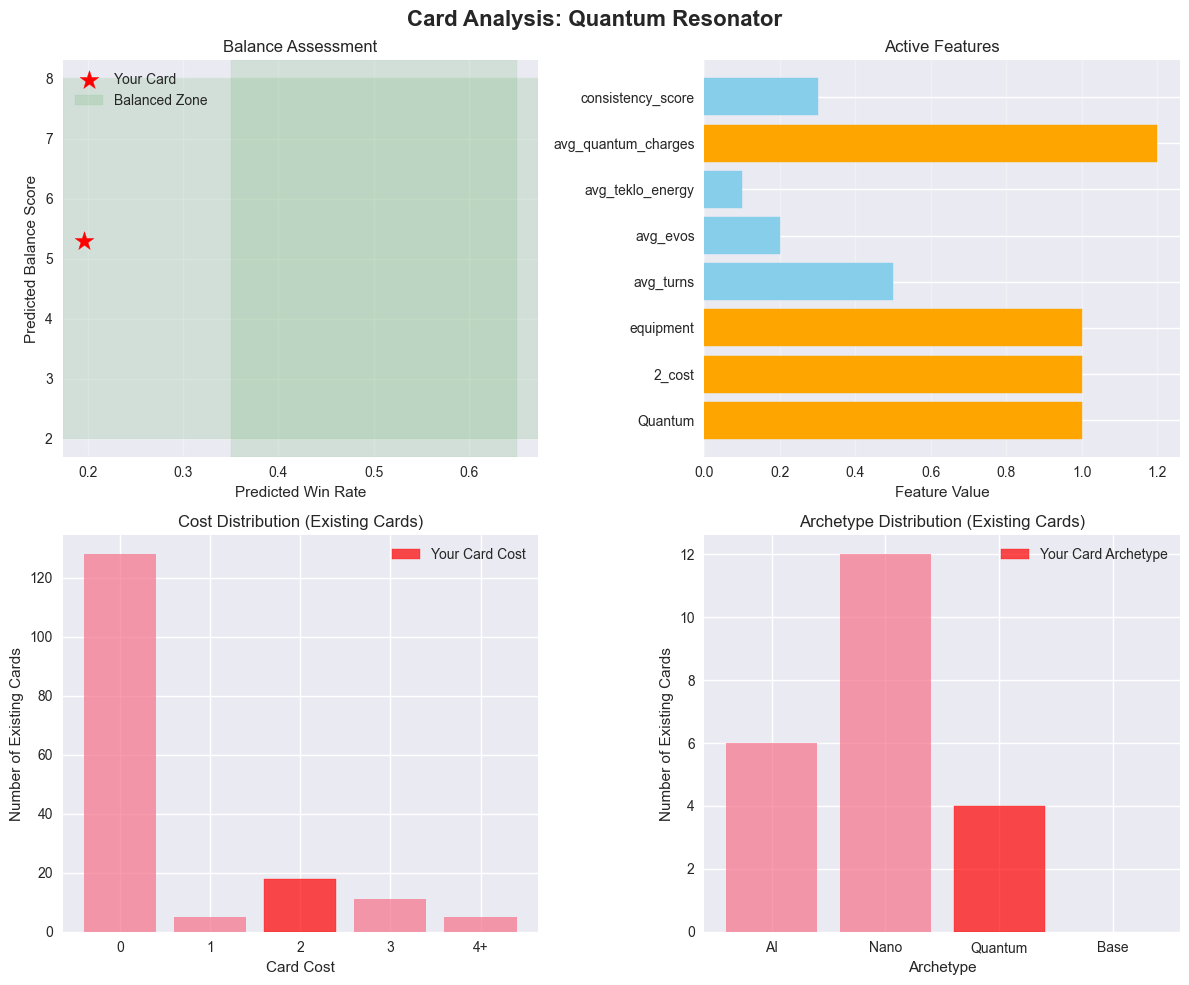


📈 Visualization complete for 'Quantum Resonator'


In [11]:
# Create visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Card Analysis: {new_card.name}', fontsize=16, fontweight='bold')

# 1. Win Rate vs Balance Score
ax1.scatter([new_card.predicted_win_rate], [new_card.predicted_balance_score], 
           s=200, c='red', marker='*', label='Your Card', zorder=5)

# Add reference zones
ax1.axhspan(2, 8, alpha=0.1, color='green', label='Balanced Zone')
ax1.axvspan(0.35, 0.65, alpha=0.1, color='green')
ax1.set_xlabel('Predicted Win Rate')
ax1.set_ylabel('Predicted Balance Score')
ax1.set_title('Balance Assessment')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Feature Comparison
feature_names = list(active_features.keys())
feature_values = list(active_features.values())

if feature_names:
    bars = ax2.barh(feature_names, feature_values)
    ax2.set_xlabel('Feature Value')
    ax2.set_title('Active Features')
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Color bars based on value
    for bar, value in zip(bars, feature_values):
        if value > 0.5:
            bar.set_color('orange')
        else:
            bar.set_color('skyblue')
else:
    ax2.text(0.5, 0.5, 'No active features\n(binary features = 0)', 
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Active Features')

# 3. Cost Distribution Context
if analyzer and hasattr(analyzer, 'ml_data') and analyzer.ml_data is not None:
    cost_cols = ['0_cost', '1_cost', '2_cost', '3_cost', '4_plus_cost']
    cost_counts = []
    cost_labels = ['0', '1', '2', '3', '4+']
    
    for col in cost_cols:
        if col in analyzer.ml_data.columns:
            count = analyzer.ml_data[col].sum()
            cost_counts.append(count)
        else:
            cost_counts.append(0)
    
    bars = ax3.bar(cost_labels, cost_counts, alpha=0.7)
    
    # Highlight your card's cost
    if new_card.cost < len(bars):
        bars[new_card.cost].set_color('red')
        bars[new_card.cost].set_label('Your Card Cost')
    
    ax3.set_xlabel('Card Cost')
    ax3.set_ylabel('Number of Existing Cards')
    ax3.set_title('Cost Distribution (Existing Cards)')
    ax3.legend()
else:
    ax3.text(0.5, 0.5, 'No existing data\nfor comparison', 
             ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Cost Distribution')

# 4. Archetype Distribution Context  
if analyzer and hasattr(analyzer, 'ml_data') and analyzer.ml_data is not None:
    archetype_cols = ['AI', 'Nano', 'Quantum', 'Base']
    archetype_counts = []
    
    for col in archetype_cols:
        if col in analyzer.ml_data.columns:
            count = analyzer.ml_data[col].sum()
            archetype_counts.append(count)
        else:
            archetype_counts.append(0)
    
    bars = ax4.bar(archetype_cols, archetype_counts, alpha=0.7)
    
    # Highlight your card's archetype
    if new_card.archetype in archetype_cols:
        idx = archetype_cols.index(new_card.archetype)
        bars[idx].set_color('red')
        bars[idx].set_label('Your Card Archetype')
    
    ax4.set_xlabel('Archetype')
    ax4.set_ylabel('Number of Existing Cards')
    ax4.set_title('Archetype Distribution (Existing Cards)')
    ax4.legend()
else:
    ax4.text(0.5, 0.5, 'No existing data\nfor comparison', 
             ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Archetype Distribution')

plt.tight_layout()
plt.show()

print(f"\n📈 Visualization complete for '{new_card.name}'")

## Save Proposal

In [12]:
# Save the card proposal
proposals_dir = Path("../data/card_proposals")
proposals_dir.mkdir(exist_ok=True)

# Create filename from card name
safe_name = new_card.name.lower().replace(" ", "_").replace("/", "_")
filename = f"{safe_name}_proposal.json"
filepath = proposals_dir / filename

# Save to JSON
with open(filepath, 'w') as f:
    json.dump(new_card.to_dict(), f, indent=2)

print(f"💾 Saved proposal to: {filepath}")

# Also add to a master proposals file
master_file = proposals_dir / "all_proposals.json"
proposals_list = []

if master_file.exists():
    with open(master_file, 'r') as f:
        proposals_list = json.load(f)

# Add or update this proposal
proposal_dict = new_card.to_dict()
proposal_dict['created_at'] = pd.Timestamp.now().isoformat()

# Remove any existing proposal with the same name
proposals_list = [p for p in proposals_list if p['name'] != new_card.name]
proposals_list.append(proposal_dict)

with open(master_file, 'w') as f:
    json.dump(proposals_list, f, indent=2)

print(f"📝 Added to master proposals list: {len(proposals_list)} total proposals")

💾 Saved proposal to: ..\data\card_proposals\quantum_resonator_proposal.json
📝 Added to master proposals list: 1 total proposals


## Load and Compare Existing Proposals

In [13]:
# Load all existing proposals for comparison
master_file = Path("../data/card_proposals/all_proposals.json")

if master_file.exists():
    with open(master_file, 'r') as f:
        all_proposals = json.load(f)
    
    print(f"📋 Found {len(all_proposals)} existing proposals:")
    
    # Create summary DataFrame
    summary_data = []
    for prop in all_proposals:
        summary_data.append({
            'Name': prop['name'],
            'Type': prop['card_type'].title(),
            'Cost': prop['cost'],
            'Archetype': prop['archetype'],
            'Win Rate': f"{prop.get('predicted_win_rate', 0):.1%}",
            'Balance Score': f"{prop.get('predicted_balance_score', 0):.1f}",
            'Assessment': prop.get('balance_assessment', 'Unknown').replace('🔴 ', '').replace('🟢 ', '').replace('🟡 ', '').replace('🔵 ', '')
        })
    
    df_summary = pd.DataFrame(summary_data)
    
    # Display summary table
    print("\n" + "="*80)
    print(df_summary.to_string(index=False))
    print("="*80)
    
    # Show distribution
    if len(all_proposals) > 1:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Win rate distribution
        win_rates = [p.get('predicted_win_rate', 0.5) for p in all_proposals]
        ax1.hist(win_rates, bins=10, alpha=0.7, edgecolor='black')
        ax1.axvline(new_card.predicted_win_rate, color='red', linestyle='--', 
                   label=f'Your Card ({new_card.predicted_win_rate:.1%})')
        ax1.set_xlabel('Predicted Win Rate')
        ax1.set_ylabel('Number of Proposals')
        ax1.set_title('Win Rate Distribution')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Balance score distribution
        balance_scores = [p.get('predicted_balance_score', 5.0) for p in all_proposals]
        ax2.hist(balance_scores, bins=10, alpha=0.7, edgecolor='black')
        ax2.axvline(new_card.predicted_balance_score, color='red', linestyle='--',
                   label=f'Your Card ({new_card.predicted_balance_score:.1f})')
        ax2.set_xlabel('Predicted Balance Score')
        ax2.set_ylabel('Number of Proposals')
        ax2.set_title('Balance Score Distribution')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
else:
    print("📝 No existing proposals found. This is your first one!")

📋 Found 1 existing proposals:

             Name      Type  Cost Archetype Win Rate Balance Score                                     Assessment
Quantum Resonator Equipment     2   Quantum    19.6%           5.3 UNDERPOWERED - Consider increasing power level


## Next Steps

After creating your card proposal, consider:

1. **Playtesting**: Test the card in actual games to validate predictions
2. **Iteration**: Adjust cost, abilities, or archetype based on results
3. **Data Collection**: Add playtesting results to improve future predictions
4. **Community Feedback**: Share proposals for expert review

To improve prediction accuracy:
- Run more gameplay simulations
- Deploy ML models to SageMaker for better predictions
- Collect expert balance ratings for training data

In [14]:
print("🎉 Card proposal process complete!")
print(f"\nYour card '{new_card.name}' has been analyzed and saved.")
print("\nRemember to:")
print("✓ Playtest the card")
print("✓ Gather feedback")
print("✓ Iterate on the design")
print("✓ Update ML data with results")

🎉 Card proposal process complete!

Your card 'Quantum Resonator' has been analyzed and saved.

Remember to:
✓ Playtest the card
✓ Gather feedback
✓ Iterate on the design
✓ Update ML data with results
